In [3]:
import pandas as pd
import numpy as np
import pdfplumber
import pytesseract
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
from PIL import Image
import re
import os
import platform

In [2]:
pd.read_csv('data\list_company.csv')

,company_name_invoice,company_name_registery,ID_TVA,parent_company
0,BRILL_SA,société_du_parking_brill,LU22991326,0
1,Parking_Brill_SA,société_du_parking_brill,LU22991326,NaN
2,Parking_Brill,société_du_parking_brill,LU22991326,NaN
3,SPBS_SA,société_du_parking_brill,LU22991326,NaN
4,parking d'esch,societe du parking d'Esch-sur-Alzette,LU20558988,0
5,SPESA,societe du parking d'Esch-sur-Alzette,LU20558988,0
6,parking_hotel_de_ville_esch_alzette,societe du parking d'Esch-sur-Alzette,LU20558988,0
7,esch_hotel_de_ville,societe du parking d'Esch-sur-Alzette,LU20558988,0
8,parking_monterey,SPAM,LU16825646,0
9,MONTEREY_S.A.,SPAM,LU16825646,0


In [5]:
platform.system()

'Windows'

In [6]:
from dotenv import load_dotenv
load_dotenv(dotenv_path='./src/.env')

True

In [7]:
os.getenv("TESSERACT_PATH_WIN")

'C:/Program Files/Tesseract-OCR/tesseract.exe'

In [8]:
os.getenv("TESSERACT_PATH_WIN", "tesseract")

'C:/Program Files/Tesseract-OCR/tesseract.exe'

In [2]:
from dotenv import load_dotenv

In [10]:
import platform

platform.system()

'Windows'

In [11]:
list_company = ['brinks','avocat a la cour','sdworx','muller & wegener','mettler','marc decker','3c payment',
                'vigicore','ibgraf','rentokil initial','foyer','nespresso','scheidt & bachman','uncos']

In [7]:
#chemin de pytesseract.exe
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [3]:
dk = pd.read_csv('data\list_company.csv')
dk

,company_name_invoice,company_name_registery,ID_TVA,parent_company
0,SPESA,societe du parking d'Esch-sur-Alzette,LU20558988,NaN
1,THEATRE,société_du_parking_theatre,LU10403280,NaN
2,BRILL,société_du_parking_brill,LU22991326,NaN
3,LITHOPARK,lithpoark,LU11205504,NaN
4,MONTEREY S.A.,SPAM,LU16825646,NaN
5,ALBERT PHILLIPE,ALBERT_PHILLIPE,LU10403280,SPG
6,AM DUERF,AM DUERF,LU10403280,SPG
7,BEI DER EIL,BEI_DER_EIL,LU10403280,SPG
8,THEATRE,BLOBIERG,LU10403280,SPG
9,BOUILLON,BOUILLON,LU10403280,SPG


In [4]:
company_name = ('SPG', 'BOUILLON')

In [36]:
dg = pd.read_csv('./data\supplier_copy.csv')
dg

,entreprise,ID_TVA
0,3c payment,LU28264772
1,avocat a la cour,LU23014984
2,bilia,LU21427047
3,brinks,LU10627004
4,climalux,LU19097974
5,elco,LU20075964
6,foyer assurance,LU14673765
7,hotel-standinn,LU18856361
8,ibgraf,LU14208743
9,kone,LU19882405675


In [35]:
dg = pd.read_csv('./data\supplier_copy.csv')
dg = dg.drop(['Unnamed: 0.1','Unnamed: 0'],axis = 1)
dg.sort_values(by="entreprise").to_csv('data\supplier_copy.csv',index=False)

In [19]:
dg.drop_duplicates().shape

(24, 2)

In [28]:
dg.sort_values(by="entreprise").to_csv('data\supplier_copy.csv')

In [9]:
directory_company_match = dk.loc[dk['company_name_invoice'] == company_name[1]].values

In [11]:
directory_company_match[0]

array(['BOUILLON', 'BOUILLON', 'LU10403280', 'SPG'], dtype=object)

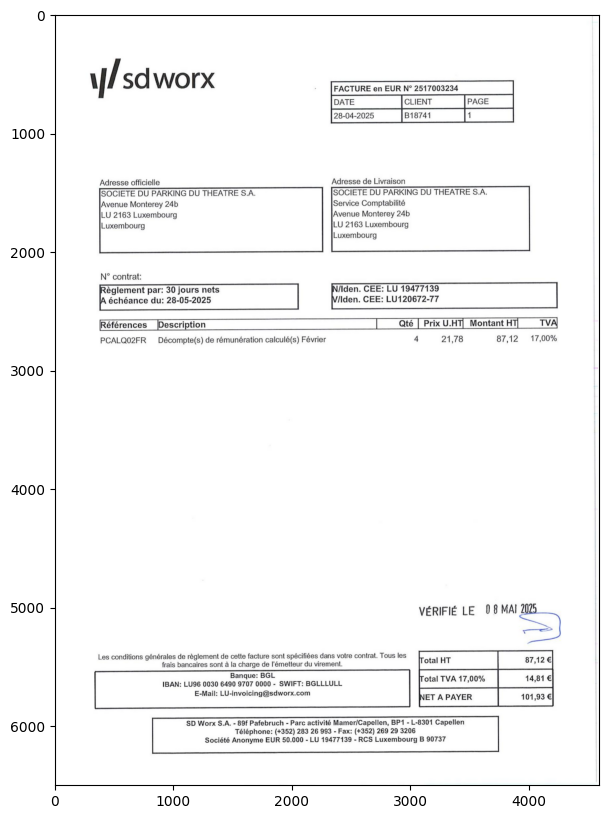

In [45]:

#conversion du chaque page du pdf en image
image_train = convert_from_path(r'data\output\SPT\new_supplier\facture20250709_004704.pdf')
plt.figure(figsize=(10,10))
plt.imshow(image_train[0])

In [46]:
text_1 = pytesseract.image_to_string(image_train[0]).replace(" ","").strip()
text_1

'y/sdworx\n\nFACTUREenEURN°2517003234\nDATECLIENTPAGE\n28-04-2025B18741\n\nAdresseofficielleAdressedeLivraison\n\nSOCIETEDUPARKINGDUTHEATRES.A.SOCIETEDUPARKINGDUTHEATRES.A.\nAvenueMonterey24bServiceComptabilité\n\nLU2163LuxembourgAvenueMonterey24b\n\nLuxembourgLU2163Luxembourg\n\nLuxembourg\n\nN°contrat:\n\nRéglementpar:30joursnets/Iden.CEE:LU19477139\n\n\\échéancedu:28-05-2025/Iden.CEE:LU120672-77\n\nRéférences[Description————CS~—‘C—~C—~SCSCCCC|St|PrixU.HT]|MontantHT]TVA\nPCALQ02FRDécompte(s)deremunérationcalculé(s)Feévrier421,7887,1217,00%\n\nVERIFIELE08MAI—\na\naes\n\notalHT87,12€\notalTVA17,00%14,81€\nETAPAYER101,93€\n\nSDWorxS.A.-89fPafebruch-ParcactivitéMamer/Capellen,BP1-L-8301Capellen\nTéléphone:(+352)28326993-Fax:(+352)269293206\n\nLesconditionsgénéralesderéglementdecettefacturesontspécifiéesdansvotrecontrat.Tousles\nfraisbancairessontalachargedel’émetteurduvirement.\n\nBanque:BGL\nIBAN:LU960030649097070000-SWIFT:BGLLLULL\n\nE-Mail:LU-invoicing@sdworx.com\n\nSociétéAnonymeEUR5

In [47]:
import unicodedata
import re

text_2 = text_1.lower()
# print(text_2)
text_3 = unicodedata.normalize('NFKD',text_2)
print(text_3)
# print(mot_sans_accents)

y/sdworx

factureeneurn°2517003234
dateclientpage
28-04-2025b18741

adresseofficielleadressedelivraison

societeduparkingdutheatres.a.societeduparkingdutheatres.a.
avenuemonterey24bservicecomptabilité

lu2163luxembourgavenuemonterey24b

luxembourglu2163luxembourg

luxembourg

n°contrat:

réglementpar:30joursnets/iden.cee:lu19477139

\échéancedu:28-05-2025/iden.cee:lu120672-77

références[description————cs~—‘c—~c—~scscccc|st|prixu.ht]|montantht]tva
pcalq02frdécompte(s)deremunérationcalculé(s)feévrier421,7887,1217,00%

verifiele08mai—
a
aes

otalht87,12€
otaltva17,00%14,81€
etapayer101,93€

sdworxs.a.-89fpafebruch-parcactivitémamer/capellen,bp1-l-8301capellen
téléphone:(+352)28326993-fax:(+352)269293206

lesconditionsgénéralesderéglementdecettefacturesontspécifiéesdansvotrecontrat.tousles
fraisbancairessontalachargedel’émetteurduvirement.

banque:bgl
iban:lu960030649097070000-swift:bglllull

e-mail:lu-invoicing@sdworx.com

sociétéanonymeeur50.000-lu19477139-rcsluxemb

In [48]:
'sdworx' in text_3

True

In [35]:
text_4 = text_3.encode('ASCII','ignore')
text_4
text_5 = text_4.decode('utf-8')
print(text_5)


_{paymentpartofplanet

societeduparkingdutheatres.a.

24b,avenuemonterey
l-2163luxembourg

luxembourg
invoicen:349257
invoicedate:2024-11-30november2024
duedate:2024-12-30credit&debitcardprocessingfees

billingaccountn:140021
yourvat/taxidn:lu12067277

locationlocationname#transprocessedamountinvoicingbasisfeecurrency

239008parkingtheatres.a.(acsc&p)
total1:127.05eur

107344parkingtheatre104,367.902,048.64eur
contractterms:

transactionfee:0.1452eur

minimummonthlyfee:127.05eur

includingfreetransactions:750

transactionfee:0.088eur

2,175.69eur

fixcostdescriptionfeecurrency

rental552.88eur

total2

total1+22,728.57
vattotal463.86

grandtotal3,.9a45

pleasealwaysmentionthecustomernumberonpayments.
wekindlyaskyoutopaytheamountwithin30days,tothebankaccountnumber:
ibanlu480024134879700000atdexiabilbic:billlull

foranybillingenquiries,pleasecontact:billing.1lu@3cpayment.comverifie[fe18dec,?.

3cpaymentluxembourgs.a.-5-7rueleonlaval
l-3372lleudelange-luxembourg
vatn/lu28264772traderegist

In [31]:
text_6 = text_5.replace("-", " ").replace("_", " ")
text_6

' {paymentpartofplanet\n\nsocieteduparkingdutheatres.a.\n\n24b,avenuemonterey\nl 2163luxembourg\n\nluxembourg\ninvoicen:349257\ninvoicedate:2024 11 30november2024\nduedate:2024 12 30credit&debitcardprocessingfees\n\nbillingaccountn:140021\nyourvat/taxidn:lu12067277\n\nlocationlocationname#transprocessedamountinvoicingbasisfeecurrency\n\n239008parkingtheatres.a.(acsc&p)\ntotal1:127.05eur\n\n107344parkingtheatre104,367.902,048.64eur\ncontractterms:\n\ntransactionfee:0.1452eur\n\nminimummonthlyfee:127.05eur\n\nincludingfreetransactions:750\n\ntransactionfee:0.088eur\n\n2,175.69eur\n\nfixcostdescriptionfeecurrency\n\nrental552.88eur\n\ntotal2\n\ntotal1+22,728.57\nvattotal463.86\n\ngrandtotal3,.9a45\n\npleasealwaysmentionthecustomernumberonpayments.\nwekindlyaskyoutopaytheamountwithin30days,tothebankaccountnumber:\nibanlu480024134879700000atdexiabilbic:billlull\n\nforanybillingenquiries,pleasecontact:billing.1lu@3cpayment.comverifie[fe18dec,?.\n\n3cpaymentluxembourgs.a. 5 7rueleonlaval\nl 3

In [33]:
text_7 = text_6.replace("-", " ").replace("_", " ")
text_8 = re.sub(r"[^\w\s]", "", text_7)  
text_9 = re.sub(r"\s+", "", text_8)

text_9      

'paymentpartofplanetsocieteduparkingdutheatresa24bavenuemontereyl2163luxembourgluxembourginvoicen349257invoicedate20241130november2024duedate20241230creditdebitcardprocessingfeesbillingaccountn140021yourvattaxidnlu12067277locationlocationnametransprocessedamountinvoicingbasisfeecurrency239008parkingtheatresaacscptotal112705eur107344parkingtheatre10436790204864eurcontracttermstransactionfee01452eurminimummonthlyfee12705eurincludingfreetransactions750transactionfee0088eur217569eurfixcostdescriptionfeecurrencyrental55288eurtotal2total12272857vattotal46386grandtotal39a45pleasealwaysmentionthecustomernumberonpaymentswekindlyaskyoutopaytheamountwithin30daystothebankaccountnumberibanlu480024134879700000atdexiabilbicbilllullforanybillingenquiriespleasecontactbilling1lu3cpaymentcomverifiefe18dec3cpaymentluxembourgsa57rueleonlavall3372lleudelangeluxembourgvatnlu28264772traderegisterb202905'

In [44]:
'sptsa' in text_9

False

In [ ]:
#selection des pages de facture contenant la mention verifiée
import unicodedata


image_facture_keep=[]


for i,image in enumerate(image_train):
    text = pytesseract.image_to_string(image)
    print(text)
    if "verifie le" in text.lower():
        image_facture_keep.append(image)
        for elmt in list_company:
            if elmt in text.lower():
                print(text.lower)
                print('STOPPPPPPPPPPPPPPP')
                elmt = elmt.strip()
                elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
                elmt = elmt.replace(' ','_')
                print(elmt)
                if not os.path.exists(elmt):
                    os.makedirs(elmt)
                    print(f"dossier {elmt} créé")
                else:
                    print(f"dossier {elmt} déjà existant")
                image.convert("RGB").save(os.path.join(elmt,f"facture{i+1}.pdf"))



In [ ]:
list_company_guillaume = pd.read_csv()

In [ ]:
clean_text = text.lower().replace(" ","").replace("-","")

In [ ]:
for i,image in enumerate(image_train):
    text = pytesseract.image_to_string(image)
    print(text)
    if "verifie le" in text.lower():
        image_facture_keep.append(image)
        clean_text = text.lower().replace(" ","").replace("-","")
        for elmt in list_company_guillaume:
            if elmt.lower().replace(" ","") in clean_text:
               elmt = elmt.strip()
               elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
               elmt = elmt.replace(' ','_')
               print(elmt)
               if not os.path.exists(os.path.join('SPG',):

        
        
        
        
        for elmt in list_company:
            if elmt in text.lower():
                print(text.lower)
                print('STOPPPPPPPPPPPPPPP')
                elmt = elmt.strip()
                elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
                elmt = elmt.replace(' ','_')
                print(elmt)
                if not os.path.exists(elmt):
                    os.makedirs(elmt)
                    print(f"dossier {elmt} créé")
                else:
                    print(f"dossier {elmt} déjà existant")
                image.convert("RGB").save(os.path.join(elmt,f"facture{i+1}.pdf"))

In [ ]:
image_facture_keep=[]


for i,image in enumerate(image_train):
    text = reader.readtext(np.array(image))
    detected_text = [elmt[1] for elmt in text]
    print(detected_text)
    
    if "verifie le" in detected_text:
        image_facture_keep.append(image)
        for elmt in list_company:
            if elmt in text.lower():
                print(text.lower)
                print('STOPPPPPPPPPPPPPPP')
                elmt = elmt.strip()
                elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
                elmt = elmt.replace(' ','_')
                print(elmt)
                if not os.path.exists(elmt):
                    os.makedirs(elmt)
                    print(f"dossier {elmt} créé")
                else:
                    print(f"dossier {elmt} déjà existant")
                image.convert("RGB").save(os.path.join(elmt,f"facture{i+1}.pdf"))

In [ ]:
#on convertit chaque image de facture en un fichier pdf

for i, img in enumerate(image_facture_keep):
    path = os.path.join()
    img.convert("RGB").save(f"facture_{i+1}.pdf")

In [51]:
['brinks','avocat a la cour','sdworx','muller & wegener','mettler','marc decker','3c payment','vigicore','ibgraf','rentokil initial','foyer','nespresso','scheidt & bachman']

['brinks',
 'avocat a la cour',
 'sdworx',
 'muller & wegener',
 'mettler',
 'marc decker',
 '3c payment',
 'vigicore',
 'ibgraf',
 'rentokil initial',
 'foyer',
 'nespresso',
 'scheidt & bachman']

In [16]:
df = pd.read_csv('./data/company.csv',sep=',')
df.head()

,entreprise,ID_TVA
0,brinks,LU10627004
1,sd workx,LU19477139


In [54]:
# config.py
df = pd.read_csv('company.csv',sep=',')
LIST_COMPANY = list(df['entreprise'])
NEW_COMPANY = "new_company"
TESSERACT_PATH = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
INPUT_PDF = "20250523080415005.pdf"
OUTPUT_DIR = "output"

In [55]:
#utils
def check_invoice(text):
    """
    check the invoice's page where "verifie le " is written

    Args:
        text (str): ten invoice's text

    Returns:
        True or False
    """
    return "verifie le" in text.lower()



def check_company(text, company_list=LIST_COMPANY):
    """
    check the company name in the invoice

    return
        company name or None

    """    
    for company_name in company_list:
        if company_name.lower().replace(" ","") in text.lower().replace(" ",""):
            return company_name
    
    return None



def normalise_company_name(text):
    """
    preprocess the companies name directory

    Args:
        text (str): company's name

    Returns:
        text
    """
    
    text = text.strip()
    text = re.sub(r'[<>:"/\\|?*]','',text)
    text = text.replace(' ','_')
    return text


def convert_pdf_to_PIL(INPUT_PDF):
    image = convert_from_path(INPUT_PDF)
    return image


def make_directory_company(directory,output_dir=OUTPUT_DIR):
    """
    Create a directory if it doesn't exist.

    Args:
        directory (str): The path of the directory to be created.

    Returns:
        None
    """
    path = os.path.join(output_dir,directory)
    print(path)
    
    if not (os.path.exists(path)):
        os.makedirs(path)
        print(f"dossier {directory} créé")
        return path
    else:
        print(f"dossier {directory} déjà existant")
        return path
    



In [ ]:
def convert_invoice_pdf(input_pdf=INPUT_PDF,new_company=NEW_COMPANY):
    """
    convert the Image PIL into pdf files

    Args:
        image : invoice image 
    """
    
    images = convert_pdf_to_PIL(input_pdf)
    
    for i,image in enumerate(images):
        text = pytesseract.image_to_string(image)
        
        
        if check_invoice(text):
            company_name = check_company(text)

            if company_name:
                norm_name = normalise_company_name(company_name)

            else:
                norm_name = normalise_company_name(new_company)

            dir_path = make_directory_company(directory=norm_name)
            image.convert('RGB').save(os.path.join(dir_path,f"facture{i+1}.pdf"))
            print(f"facture{i+1}.pdf enregistré dans {dir_path}")

        
        else:
            print("Factures non validées")
                    
                
        
        

In [57]:
convert_invoice_pdf()

output\brinks
dossier brinks créé
facture1.pdf enregistré dans output\brinks
output\olinn
dossier olinn créé
facture2.pdf enregistré dans output\olinn
output\reiserbann
dossier reiserbann créé
facture3.pdf enregistré dans output\reiserbann
output\Taxes_communales
dossier Taxes_communales créé
facture4.pdf enregistré dans output\Taxes_communales
Factures non validées
output\climalux
dossier climalux créé
facture6.pdf enregistré dans output\climalux
Factures non validées
output\climalux
dossier climalux déjà existant
facture8.pdf enregistré dans output\climalux
Factures non validées
output\uncos
dossier uncos créé
facture10.pdf enregistré dans output\uncos
Factures non validées
Factures non validées
Factures non validées
Factures non validées
output\3C_Payment
dossier 3C_Payment créé
facture15.pdf enregistré dans output\3C_Payment


In [ ]:
import shutil, os

shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

In [2]:
import os

In [7]:
INPUT_PDF_FOLDER = "data/input"

In [8]:
os.listdir(INPUT_PDF_FOLDER)

['20250523080415005.pdf', '20250523113438226.pdf', '20250523115647130.pdf']

In [11]:
dg = pd.read_csv('data/company.csv')
dg

,entreprise,ID TVA
0,brinks,LU10627004
1,sd workx,LU19477139
2,uncos,LU23553238
3,3C Payment,LU28264772
4,SNCT,LU251806425
5,olinn,LU10467309
6,reiserbann,LU32255115
7,Taxes communales,LU10286570
8,climalux,LU19097974
9,Bilia,LU21427047


In [12]:
from datetime import datetime

In [ ]:
datetime.now().strftime("%Y%m%d_%H%M%S")

datetime.datetime(2025, 6, 6, 22, 49, 43, 346573)

In [3]:
import os

In [4]:
print(__file__)

NameError: name '__file__' is not defined